# Импорт необходимых зависимостей и реализация функций

In [1]:
# Импортируем необходимые библиотеки и зависимости
import cv2

from google.colab.patches import cv2_imshow

import matplotlib.pyplot as plt

import numpy as np

import seaborn as sns
from skimage.io import imread, imsave, imshow

import time

In [2]:
# Функция преобразования изображения в оттенки серого, визуализация оригинального и ч/б изображения
def load_image(path):

  """
  path - путь к оригинальному изображению
  """

  # Отлавливаем ошибку в случае некорректного пути
  try:
    # Чтение оригинального цветного изображения
    image = cv2.imread(path)

    # Преобразование изображения в ч/б формат
    img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Создание исходной копии цветного изображения
    original_img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Визуализация

    # Отображение изображения и его исходной копии
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)

    plt.imshow(original_img)
    plt.title('Цветное изображение')
    plt.axis('off')  # Скрыть оси

    plt.subplot(1, 2, 2)
    plt.imshow(img, cmap='gray')
    plt.title('Черно-белое изображение')
    plt.axis('off')  # Скрыть оси

    # Отметка об успехе
    plt.suptitle('Изображение загружено успешно', fontsize=16)
    plt.show()

    # Возвращает ч/б копию изображения
    return img

  # Если путь некорректный
  except:
    print('Введите корректный путь')

In [3]:
# Функция нахождения гистограммы изображения в виде массива
def get_array_histogram_image(img):

  """
  img - изображение, для которого находится массив эквализации гистограмм
  """

  # Создает массив из 256 элементов, инициализированных нулями
  array_histogram_image = np.zeros(256)

  # Двойной цикл for проходит по всем пикселям изображения
  # (img.shape[0] - количество строк, img.shape[1] - количество столбцов).
  for i in range(img.shape[0]):
    for j in range(img.shape[1]):
      # Для каждого пикселя изображения увеличивается соответствующий элемент массива array_histogram_image
      array_histogram_image[img[i][j]] += 1

  # Возвращает массив количества элементов с яркостью от 0 до 255
  return array_histogram_image

In [4]:
# Создание гистограммы изображения и отображение ее на конечном выводе (снизу в центре, снизу справа)
def show_hist(ax, histogram_image, text):

    """
    ax - номер подграфика конечного вывода, под которым выведется гистограмма
    histogram_image - массив количества элементов с яркостью от 0 до 255 (находится функцией get_array_histogram_image)
    text - описание заголовка для подграфика
    """

    # Настройки библиотеки Seaborn по умолчанию
    sns.reset_defaults()
    # Создает столбчатую диаграмму с использованием Seaborn
    sns.barplot(x=np.arange(256), y=histogram_image, palette='viridis', ax=ax)

    # Настройка заголовка и осей
    ax.set_title(text)
    ax.set_xlabel('Яркость пикселя')
    ax.set_ylabel('Частота, логарифмический масштаб')
    ax.set_xticks(np.arange(0, 256, step=17))

    # Создает на оси метки от 0 до 255 с шагом 17 повернутые на 45°
    ax.set_xticklabels(np.arange(0, 256, step=17), rotation=45)
    # Логарифмический масштаб по оси y
    ax.set_yscale('log')

In [5]:
# Функция нахождения изображения эквализации гистограмм
def get_equalization_img(img, histogram_image):

  """
  img - изображение, к которому применяется эквализация гистограмм
  histogram_image - массив количества элементов с яркостью от 0 до 255 (находится функцией get_array_histogram_image)
  """

  # Создается пустое изображение по размерам входного, инициализированное нулями
  equalization_img = np.zeros((img.shape[0], img.shape[1]))
  # Находится подсчет cdf функции до элемента x
  cdf = [sum(histogram_image[i] for i in range(x + 1)) for x in range(256)]
  # Находится минимальный элемент функции cdf такой, что он > 0
  cdf_min = min([i for i in cdf if i > 0])

  # Двойной цикл по всем пикселям изображения
  for i in range(img.shape[0]):
    for j in range(img.shape[1]):
      # Присваиваем каждому пикселю изображения значение, высчитанное по формуле для эквализации гистограмм
      equalization_img[i][j] = round(255 * ((cdf[img[i][j]] - cdf_min) / (img.shape[0] * img.shape[1] - 1)))

  # Возвращаем полученное изображение эквализации гистограмм
  return equalization_img.astype(np.uint8)

In [6]:
# Функция визуализации cdf для исходного, изображения преобразованного оператором и его эквализации
def show_cdf(ax, img, hist, histogram_image, histogram_equl_image):

    """
    ax - номер подграфика конечного вывода, под которым выведется cdf
    img - изображение, от которого нужны размеры вертикали и горизонтали
    hist - массив количества элементов исходного изображения с яркостью от 0 до 255 (находится функцией get_array_histogram_image)
    histogram_image - массив количества элементов изображения оператора с яркостью от 0 до 255 (находится функцией get_array_histogram_image)
    histogram_equl_image - массив количества элементов эквализованного изображения оператора с яркостью от 0 до 255 (находится функцией get_array_histogram_image)
    """

    # Визуализируем на графике кривую cdf для исходного изображения
    sns.lineplot(x=np.arange(256), y=[sum(hist[:i]) / (img.shape[0] * img.shape[1]) for i in np.arange(256)], palette=None, marker='o', label='cdf изображения', ax=ax)
    # Визуализируем на графике кривую cdf для изображения, преобразованного оператором
    sns.lineplot(x=np.arange(256), y=[sum(histogram_image[:i]) / (img.shape[0] * img.shape[1]) for i in np.arange(256)], palette=None, marker='o', label='cdf оператора', ax=ax)
    # Визуализируем на графике кривую cdf для эквализации изображения, преобразованного оператором
    sns.lineplot(x=np.arange(256), y=[sum(histogram_equl_image[:i]) / (img.shape[0] * img.shape[1]) for i in np.arange(256)], palette=None, marker='o', label='cdf эквализации гистограмм', ax=ax)

    # Настройка заголовка и осей
    ax.set_title('Сравнение cdf изображения оператора и эквализации')
    ax.set_xlabel('Яркость пикселя')
    ax.set_ylabel('Кумулятивная сумма')
    ax.set_xticks(np.arange(0, 256, step=17))

    # Создает на оси метки от 0 до 255 с шагом 17 повернутые на 45°
    ax.set_xticklabels(np.arange(0, 256, step=17), rotation=45)
    # Подпись к графикам будет расположена сверху справа
    ax.legend(loc='upper right')
    ax.set_ylim(-0.05, 1.45)

In [7]:
# Пользовательская функция свертки
def my_filter_function(image, kernel):

  """
  image - изображение, к которому применяется операция свертки
  kernel - ядро свертки
  """

  # Находим длину фильтра
  length_filter = len(kernel[0])
  # Инициализируем изображение заполненное нулями вместе с рамкой
  image_for_filter = np.zeros((image.shape[0] + length_filter - 1, image.shape[1] + length_filter - 1))
  # Заполняем изображение исходным, оставляя рамки пустыми
  image_for_filter[(length_filter // 2) : -(length_filter // 2), (length_filter // 2) : -(length_filter // 2)] = image
  # Создаем результирующее изображение свертки
  result = np.zeros(image.shape)

  # Двойной цикл по всему изображению
  for i in range(length_filter // 2, image_for_filter.shape[0] - length_filter // 2):
    for j in range(length_filter // 2, image_for_filter.shape[1] - length_filter // 2):
      # Pаменяем в результирующем изображении каждый пиксель согласно свертке и оператору, обрезаем значения в пределах [0 ... 255]
      result[i - length_filter // 2, j - length_filter // 2] = max(min(round(np.sum(image_for_filter[i - length_filter // 2
                        : i + length_filter // 2 + 1, j - length_filter // 2 : j + length_filter // 2 + 1] * kernel)), 255), 0)

  # Возвращаем результат применения оператора к изображению
  return result.astype(np.uint8)

In [8]:
# Пользовательская функция для совместного применения Сорбеля Gx и Gy 1
def my_filter_function_sobel_abs(image, kernel1, kernel2):

  """
  image - изображение, к которому применяется операция свертки
  kernel1 - ядро свертки 1
  kernel2 - ядро свертки 2
  """

  # Находим длину фильтра
  length_filter = len(kernel1[0])
  # Инициализируем изображение заполненное нулями вместе с рамкой
  image_for_filter = np.zeros((image.shape[0] + length_filter - 1, image.shape[1] + length_filter - 1))
  # Заполняем изображение исходным, оставляя рамки пустыми
  image_for_filter[(length_filter // 2) : -(length_filter // 2), (length_filter // 2) : -(length_filter // 2)] = image
  # Создаем результирующее изображение свертки
  result = np.zeros(image.shape)

  # Двойной цикл по всему изображению
  for i in range(length_filter // 2, image_for_filter.shape[0] - length_filter // 2):
    for j in range(length_filter // 2, image_for_filter.shape[1] - length_filter // 2):
      # Pаменяем в результирующем изображении каждый пиксель согласно свертке и оператору, обрезаем значения в пределах [0 ... 255]
      result[i - length_filter // 2, j - length_filter // 2] = max(min(round(abs(np.sum(image_for_filter[i - length_filter // 2
                        : i + length_filter // 2 + 1, j - length_filter // 2 : j + length_filter // 2 + 1] * kernel1)) + abs(np.sum(image_for_filter[i - length_filter // 2
                        : i + length_filter // 2 + 1, j - length_filter // 2 : j + length_filter // 2 + 1] * kernel2))), 255), 0)

  # Возвращаем результат применения оператора к изображению
  return result.astype(np.uint8)

In [9]:
# Пользовательская функция для совместного применения Собеля Gx и Gy 2
def my_filter_function_sobel_sqrt(image, kernel1, kernel2):

  """
  image - изображение, к которому применяется операция свертки
  kernel1 - ядро свертки 1
  kernel2 - ядро свертки 2
  """

  # Находим длину фильтра
  length_filter = len(kernel1[0])
  # Инициализируем изображение заполненное нулями вместе с рамкой
  image_for_filter = np.zeros((image.shape[0] + length_filter - 1, image.shape[1] + length_filter - 1))
  # Заполняем изображение исходным, оставляя рамки пустыми
  image_for_filter[(length_filter // 2) : -(length_filter // 2), (length_filter // 2) : -(length_filter // 2)] = image
  # Создаем результирующее изображение свертки
  result = np.zeros(image.shape)

  # Двойной цикл по всему изображению
  for i in range(length_filter // 2, image_for_filter.shape[0] - length_filter // 2):
    for j in range(length_filter // 2, image_for_filter.shape[1] - length_filter // 2):
      # Pаменяем в результирующем изображении каждый пиксель согласно свертке и оператору, обрезаем значения в пределах [0 ... 255]
      result[i - length_filter // 2, j - length_filter // 2] = max(min(round(((np.sum(image_for_filter[i - length_filter // 2
                        : i + length_filter // 2 + 1, j - length_filter // 2 : j + length_filter // 2 + 1] * kernel1)) ** 2 + (np.sum(image_for_filter[i - length_filter // 2
                        : i + length_filter // 2 + 1, j - length_filter // 2 : j + length_filter // 2 + 1] * kernel2)) ** 2) ** 0.5), 255), 0)

  # Возвращаем результат применения оператора к изображению
  return result.astype(np.uint8)

In [10]:
# Функция визуализации преобразования операторов, cdf и гистограмм
def show_info(img, mode='Sobel Gy'):

  """
  img - исходное загружаемое изображение
  mode - режим (оператор), в котором будет работать функция (по умолчанию - Sobel Gy)
  """

  # Оператор Собеля Gx
  kernel_sobel_gx = np.array([[-1, 0, 1],
                  [-2, 0, 2],
                  [-1, 0, 1]])

  # Оператор Собеля Gy
  kernel_sobel_gy = np.array([[-1, -2, -1],
                  [0, 0, 0],
                  [1, 2, 1]])

  # Оператор Лапласа
  kernel_laplace = np.array([[0, 1, 0],
                  [1, -4, 1],
                  [0, 1, 0]])

  # Оператор Робертса Hr
  kernel_robertz_hr = np.array([[0, 0, 0],
                  [0, -1, 0],
                  [0, 0, 1]])

  # Оператор Робертса Hc
  kernel_robertz_hc = np.array([[0, 0, 0],
                  [0, 0, -1],
                  [0, 1, 0]])

  # Выбор оператора

  # Режим Собель Gy
  if mode == 'Sobel Gy':
    # Получение изображения, с применением оператора Собеля Gy
    start_time_operator = time.time()
    contour_img = my_filter_function(img, kernel_sobel_gy)
    end_time_operator = time.time()

    suptitle_text = 'Оператор Собеля Gy'
    operator_filtering_text = 'Применение оператора Собеля Gy'
    hist_text = 'Гистограмма оператора Собеля Gy'

  # Режим Собель Gx
  elif mode == 'Sobel Gx':
    # Получение изображения, с применением оператора Собеля Gx
    start_time_operator = time.time()
    contour_img = my_filter_function(img, kernel_sobel_gx)
    end_time_operator = time.time()

    suptitle_text = 'Оператор Собеля Gx'
    operator_filtering_text = 'Применение оператора Собеля Gx'
    hist_text = 'Гистограмма оператора Собеля Gx'

  # Режим Собель Gx и Gy 1
  elif mode == 'Sobel Gx & Gy abs':
    # Получение изображения, с применением совместного действия Собеля Gx и Gy 1
    start_time_operator = time.time()
    contour_img = my_filter_function_sobel_abs(img, kernel_sobel_gx, kernel_sobel_gy)
    end_time_operator = time.time()

    # Информация для корректной визуализации
    suptitle_text = 'Совместное использование Gx и Gy 1'
    operator_filtering_text = 'Совместное использование Gx и Gy 1'
    hist_text = 'Гист. совм. использование Gx и Gy 1'

  # Режим Собель Gx и Gy 2
  elif mode == 'Sobel Gx & Gy sqrt':
    # Получение изображения, с применением совместного действия Собеля Gx и Gy 2
    start_time_operator = time.time()
    contour_img = my_filter_function_sobel_sqrt(img, kernel_sobel_gx, kernel_sobel_gy)
    end_time_operator = time.time()

    # Информация для корректной визуализации
    suptitle_text = 'Совместное использование Gx и Gy 2'
    operator_filtering_text = 'Совместное использование Gx и Gy 2'
    hist_text = 'Гист. совм. использование Gx и Gy 2'

  # Режим Лаплас
  elif mode == 'laplace':
    # Получение изображения, с применением оператора Лапласа
    start_time_operator = time.time()
    contour_img = my_filter_function(img, kernel_laplace)
    end_time_operator = time.time()

    # Информация для корректной визуализации
    suptitle_text = 'Оператор Лапласа'
    operator_filtering_text = 'Применение оператора Лапласа'
    hist_text = 'Гистограмма оператора Лапласа'

  # Режим Робертс Hr
  elif mode == 'robertz Hr':
    # Получение изображения, с применением оператора Робертса Hr
    start_time_operator = time.time()
    contour_img = my_filter_function(img, kernel_robertz_hr)
    end_time_operator = time.time()

    # Информация для корректной визуализации
    suptitle_text = 'Оператор Робертса Hr'
    operator_filtering_text ='Применение оператора Робертса Hr'
    hist_text = 'Гистограмма оператора Робертса Hr'

  # Режим Робертс Hc
  elif mode == 'robertz Hc':
    # Получение изображения, с применением оператора Робертса Hc
    start_time_operator = time.time()
    contour_img = my_filter_function(img, kernel_robertz_hc)
    end_time_operator = time.time()

    # Информация для корректной визуализации
    suptitle_text = 'Оператор Робертса Hc'
    operator_filtering_text ='Применение оператора Робертса Hc'
    hist_text = 'Гистограмма оператора Робертса Hc'

  # Режим Робертс Hr и Hс
  elif mode == 'robertz Hr & Hc':
    # Получение изображения, с совместным применением операторов Робертса Hr и Hc
    start_time_operator = time.time()
    contour_img = my_filter_function_sobel_abs(img, kernel_robertz_hr, kernel_robertz_hc)
    end_time_operator = time.time()

    # Информация для корректной визуализации
    suptitle_text = 'Совместное использование Hr и Hc'
    operator_filtering_text ='Совместное использование Hr и Hc'
    hist_text = 'Гист. совм. использования Hr и Hc'

  # Нахождение гистограммы оригинального ч/б изображения
  histog = get_array_histogram_image(img)

  # Нахождение гистограммы изображения примененного оператора
  start_time_hist_operator = time.time()
  array_histogram_contour_img = get_array_histogram_image(contour_img)
  end_time_hist_operator = time.time()

  # Эквализация гистограмм изображения примененного оператора
  start_time_equalization = time.time()
  equlization_contour_img = get_equalization_img(contour_img, array_histogram_contour_img)
  end_time_equalization = time.time()

  # Нахождение гистограммы изображения эквализации гистограмм
  start_time_hist_equalization = time.time()
  array_equlization_histogram_contour_image = get_array_histogram_image(equlization_contour_img)
  end_time_hist_equalization = time.time()

  # Визуализация

  # Создания сетки графиков 2 х 3
  fig, axs = plt.subplots(2, 3, figsize=(15, 9))

  # Отображение оригинального ч/б изображения, на конечном выводе сверху слева
  axs[0, 0].imshow(img, cmap='gray')
  axs[0, 0].set_title('Черно-белое изображение')
  axs[0, 0].axis('off')  # Скрыть оси

  # Отображение изображения примененного оператора, на конечном выводе сверху в центре
  axs[0, 1].imshow(contour_img, cmap='gray')
  axs[0, 1].set_title(operator_filtering_text)
  axs[0, 1].axis('off')  # Скрыть оси

  # Отображение изображения эквализации гистограмм примененного оператора, на конечном выводе сверху справа
  axs[0, 2].imshow(equlization_contour_img, cmap='gray')
  axs[0, 2].set_title('Эквализация гистограмм')
  axs[0, 2].axis('off')  # Скрыть оси

  # Отображение cdf оригинального изображения, изображения примененного оператора и изображения эквализации гистограмм примененного оператора,
  # на конечном выводе снизу слева
  start_time_cdf = time.time()
  show_cdf(axs[1, 0], equlization_contour_img, histog, array_histogram_contour_img, array_equlization_histogram_contour_image)
  end_time_cdf = time.time()

  # Отображение гистограммы изображения примененного оператора, на конечном выводе снизу в центре
  show_hist(axs[1, 1], array_histogram_contour_img, hist_text)

  # Отображение гистограммы изображения эквализации гистограмм примененного оператора, на конечном выводе снизу справа
  show_hist(axs[1, 2], array_equlization_histogram_contour_image, 'Гистограмма эквализации')

  # Добавление общего заголовка
  plt.suptitle(suptitle_text, fontsize=25)

  # Конечный вывод
  plt.show()

  # Подсчет времени работы

  # Вычисление оператора
  print(f'Оператор был вычислен за {round(end_time_operator - start_time_operator, 2)} секунд')
  # Вычисление эквализации гистограмм
  print(f'Эквализация гистограмм была вычислена за {round(end_time_equalization - start_time_equalization, 2)} секунд')
  # Вычисление cdf
  print(f'cdf был вычислен за {round(end_time_cdf - start_time_cdf, 2)} секунд')
  # Вычисление гистограммы относительно изображения оператора
  print(f'Гистограмма изображения оператора была вычислена за {round(end_time_hist_operator - start_time_hist_operator, 2)} секунд')
  # Вычисление гистограммы относительно эквализованного изображения оператора
  print(f'Гистограмма изображения эквализованного оператора была вычислена за {round(end_time_hist_equalization - start_time_hist_equalization, 2)} секунд')

In [11]:
# Функция сравнительного анализа операторов
def show_compare_operator(img):

  """
  img - исходное загружаемое изображение
  """

  # Оператор Собеля Gx
  kernel_sobel_gx = np.array([[-1, 0, 1],
                  [-2, 0, 2],
                  [-1, 0, 1]])

  # Оператор Собеля Gy
  kernel_sobel_gy = np.array([[-1, -2, -1],
                  [0, 0, 0],
                  [1, 2, 1]])

  # Оператор Лапласа
  kernel_laplace = np.array([[0, 1, 0],
                  [1, -4, 1],
                  [0, 1, 0]])

  # Оператор Робертса Hr
  kernel_robertz_hr = np.array([[0, 0, 0],
                  [0, -1, 0],
                  [0, 0, 1]])

  # Оператор Робертса Hc
  kernel_robertz_hc = np.array([[0, 0, 0],
                  [0, 0, -1],
                  [0, 1, 0]])

  # Находим изображение оператора Собеля Gy
  start_time_sobel_gy = time.time()
  contour_img_sobel_gy = my_filter_function(img, kernel_sobel_gy)
  end_time_sobel_gy = time.time()

  # Находим изображение оператора Собеля Gx
  start_time_sobel_gx = time.time()
  contour_img_sobel_gx = my_filter_function(img, kernel_sobel_gx)
  end_time_sobel_gx = time.time()

  # Находим изображение совместного использования операторов Собеля Gx и Gy 1
  start_time_sobel_abs = time.time()
  contour_img_sobel_abs = my_filter_function_sobel_abs(img, kernel_sobel_gx, kernel_sobel_gy)
  end_time_sobel_abs = time.time()

  # Находим изображение совместного использования операторов Собеля Gx и Gy 2
  start_time_sobel_sqrt = time.time()
  contour_img_sobel_sqrt = my_filter_function_sobel_sqrt(img, kernel_sobel_gx, kernel_sobel_gy)
  end_time_sobel_sqrt = time.time()

  # Находим изображение оператора Лапласа
  start_time_laplace = time.time()
  contour_img_laplace = my_filter_function(img, kernel_laplace)
  end_time_laplace = time.time()

  # Находим изображение оператора Робертса Hr
  start_time_robertz_hr = time.time()
  contour_img_robertz_hr = my_filter_function(img, kernel_robertz_hr)
  end_time_robertz_hr = time.time()

  # Находим изображение оператора Робертса Hc
  start_time_robertz_hc = time.time()
  contour_img_robertz_hc = my_filter_function(img, kernel_robertz_hc)
  end_time_robertz_hc = time.time()

  # Находим изображение совместного использования операторов Робертса Hr и Hc
  start_time_robertz_abs = time.time()
  contour_img_robertz_abs = my_filter_function_sobel_abs(img, kernel_robertz_hr, kernel_robertz_hc)
  end_time_robertz_abs = time.time()

  # Визуализация

  # Создания сетки графиков 3 х 3
  fig, axs = plt.subplots(3, 3, figsize=(16, 16))

  # Отображение оригинального ч/б изображения, на конечном выводе сверху слева
  axs[0, 0].imshow(img, cmap='gray')
  axs[0, 0].set_title('Черно-белое изображение')
  axs[0, 0].axis('off')  # Скрыть оси

  # Отображение оператора Собеля Gy
  axs[0, 1].imshow(contour_img_sobel_gy, cmap='gray')
  axs[0, 1].set_title('Оператор Собеля Gy')
  axs[0, 1].axis('off')  # Скрыть оси

  # Отображение оператора Собеля Gx
  axs[0, 2].imshow(contour_img_sobel_gx, cmap='gray')
  axs[0, 2].set_title('Оператор Собеля Gx')
  axs[0, 2].axis('off')  # Скрыть оси

  # Отображение совместного использования операторов Собеля 1
  axs[1, 0].imshow(contour_img_sobel_abs, cmap='gray')
  axs[1, 0].set_title('Совместное использование операторов Собеля 1')
  axs[1, 0].axis('off')  # Скрыть оси

  # Отображение совместного использования операторов Собеля 2
  axs[1, 1].imshow(contour_img_sobel_sqrt, cmap='gray')
  axs[1, 1].set_title('Совместное использование операторов Собеля 2')
  axs[1, 1].axis('off')  # Скрыть оси

  # Отображение оператора Лапласа
  axs[1, 2].imshow(contour_img_laplace, cmap='gray')
  axs[1, 2].set_title('Оператор Лапласа')
  axs[1, 2].axis('off')  # Скрыть оси

  # Отображение оператора Робертса Hr
  axs[2, 0].imshow(contour_img_robertz_hr, cmap='gray')
  axs[2, 0].set_title('Оператор Робертса Hr')
  axs[2, 0].axis('off')  # Скрыть оси

  # Отображение оператора Робертса Hc
  axs[2, 1].imshow(contour_img_robertz_hc, cmap='gray')
  axs[2, 1].set_title('Оператор Робертса Hc')
  axs[2, 1].axis('off')  # Скрыть оси

  # Отображение совместного использования операторов Робертса
  axs[2, 2].imshow(contour_img_robertz_abs, cmap='gray')
  axs[2, 2].set_title('Совместное использование операторов Робертса')
  axs[2, 2].axis('off')  # Скрыть оси

  # Добавление общего заголовка
  plt.suptitle('Сравнительный анализ операторов', fontsize=25)

  # Конечный вывод
  plt.show()

  # Подсчет времени работы операторов

  # Оператор Собеля Gy
  print(f'Оператор Собеля Gy был вычислен за {round(end_time_sobel_gy - start_time_sobel_gy, 2)} секунд')
  # Оператор Собеля Gx
  print(f'Оператор Собеля Gx был вычислен за {round(end_time_sobel_gx - start_time_sobel_gx, 2)} секунд')
  # Совместное действие оператора Собеля Gx и Gy 1
  print(f'Совместное действие оператора Собеля Gx и Gy 1 было вычислено за {round(end_time_sobel_abs - start_time_sobel_abs, 2)} секунд')
  # Совместное действие оператора Собеля Gx и Gy 2
  print(f'Совместное действие оператора Собеля Gx и Gy 2 было вычислено за {round(end_time_sobel_sqrt - start_time_sobel_sqrt, 2)} секунд')
  # Оператор Лапласа
  print(f'Оператор Лапласа был вычислен за {round(end_time_laplace - start_time_laplace, 2)} секунд')
  # Оператор Робертса Hr
  print(f'Оператор Робертса Hr был вычислен за {round(end_time_robertz_hr - start_time_robertz_hr, 2)} секунд')
  # Оператор Робертса Hc
  print(f'Оператор Робертса Hc был вычислен за {round(end_time_robertz_hc - start_time_robertz_hc, 2)} секунд')
  # Совместное действие оператора Робертса Hr и Hc
  print(f'Совместное действие оператора Робертса Hr и Hc было вычислено за {round(end_time_robertz_abs - start_time_robertz_abs, 2)} секунд')

In [12]:
# Функция сравнительного анализа эквализованных операторов
def show_compare_equalization_operator(img):

  """
  img - исходное загружаемое изображение
  """

  # Оператор Собеля Gx
  kernel_sobel_gx = np.array([[-1, 0, 1],
                  [-2, 0, 2],
                  [-1, 0, 1]])

  # Оператор Собеля Gy
  kernel_sobel_gy = np.array([[-1, -2, -1],
                  [0, 0, 0],
                  [1, 2, 1]])

  # Оператор Лапласа
  kernel_laplace = np.array([[0, 1, 0],
                  [1, -4, 1],
                  [0, 1, 0]])

  # Оператор Робертса Hr
  kernel_robertz_hr = np.array([[0, 0, 0],
                  [0, -1, 0],
                  [0, 0, 1]])

  # Оператор Робертса Hc
  kernel_robertz_hc = np.array([[0, 0, 0],
                  [0, 0, -1],
                  [0, 1, 0]])

  # Вычисление изображения Собеля Gy
  contour_img_sobel_gy = my_filter_function(img, kernel_sobel_gy)
  # Вычисление гистограммы изображения Собеля Gy
  array_histogram_contour_img_sobel_gy = get_array_histogram_image(contour_img_sobel_gy)

  # Вычисление изображения Собеля Gx
  contour_img_sobel_gx = my_filter_function(img, kernel_sobel_gx)
  # Вычисление гистограммы изображения Собеля Gx
  array_histogram_contour_img_sobel_gx = get_array_histogram_image(contour_img_sobel_gx)

  # Вычисление изображения Собеля Gx & Gy 1
  contour_img_sobel_abs = my_filter_function_sobel_abs(img, kernel_sobel_gx, kernel_sobel_gy)
  # Вычисление гистограммы изображения Собеля Gx & Gy 1
  array_histogram_contour_img_sobel_abs = get_array_histogram_image(contour_img_sobel_abs)

  # Вычисление изображения Собеля Gx & Gy 2
  contour_img_sobel_sqrt = my_filter_function_sobel_sqrt(img, kernel_sobel_gx, kernel_sobel_gy)
  # Вычисление гистограммы изображения Собеля Gx & Gy 2
  array_histogram_contour_img_sobel_sqrt = get_array_histogram_image(contour_img_sobel_sqrt)

  # Вычисление изображения Лапласа
  contour_img_laplace = my_filter_function(img, kernel_laplace)
  # Вычисление гистограммы изображения Лапласа
  array_histogram_contour_img_laplace = get_array_histogram_image(contour_img_laplace)

  # Вычисление изображения Робертса Hr
  contour_img_robertz_hr = my_filter_function(img, kernel_robertz_hr)
  # Вычисление гистограммы изображения Робертса Hr
  array_histogram_contour_img_robertz_hr = get_array_histogram_image(contour_img_robertz_hr)

  # Вычисление изображения Робертса Hc
  contour_img_robertz_hc = my_filter_function(img, kernel_robertz_hc)
  # Вычисление гистограммы изображения Робертса Hc
  array_histogram_contour_img_robertz_hc = get_array_histogram_image(contour_img_robertz_hc)

  # Вычисление изображения Робертса Hr & Hc
  contour_img_robertz_abs = my_filter_function_sobel_abs(img, kernel_robertz_hr, kernel_robertz_hc)
  # Вычисление гистограммы изображения Робертса Hr & Hc
  array_histogram_contour_img_robertz_abs = get_array_histogram_image(contour_img_robertz_abs)


  # Находим эквализованное изображение оператора Собеля Gy и отработанное время
  start_time_sobel_gy = time.time()
  equlization_contour_img_sobel_gy = get_equalization_img(contour_img_sobel_gy, array_histogram_contour_img_sobel_gy)
  end_time_sobel_gy = time.time()

  # Находим эквализованное изображение оператора Собеля Gx и отработанное время
  start_time_sobel_gx = time.time()
  equlization_contour_img_sobel_gx = get_equalization_img(contour_img_sobel_gx, array_histogram_contour_img_sobel_gx)
  end_time_sobel_gx = time.time()

  # Находим эквализованное изображение совместного использования операторов Собеля Gx и Gy 1 и отработанное время
  start_time_sobel_abs = time.time()
  equlization_contour_img_sobel_abs = get_equalization_img(contour_img_sobel_abs, array_histogram_contour_img_sobel_abs)
  end_time_sobel_abs = time.time()

  # Находим эквализованное изображение совместного использования операторов Собеля Gx и Gy 2 и отработанное время
  start_time_sobel_sqrt = time.time()
  equlization_contour_img_sobel_sqrt = get_equalization_img(contour_img_sobel_sqrt, array_histogram_contour_img_sobel_sqrt)
  end_time_sobel_sqrt = time.time()

  # Находим эквализованное изображение оператора Лапласа и отработанное время
  start_time_laplace = time.time()
  equlization_contour_img_laplace = get_equalization_img(contour_img_laplace, array_histogram_contour_img_laplace)
  end_time_laplace = time.time()

  # Находим эквализованное изображение оператора Робертса Hr и отработанное время
  start_time_robertz_hr = time.time()
  equlization_contour_img_robertz_hr = get_equalization_img(contour_img_robertz_hr, array_histogram_contour_img_robertz_hr)
  end_time_robertz_hr = time.time()

  # Находим эквализованное изображение оператора Робертса Hc и отработанное время
  start_time_robertz_hc = time.time()
  equlization_contour_img_robertz_hc = get_equalization_img(contour_img_robertz_hc, array_histogram_contour_img_robertz_hc)
  end_time_robertz_hc = time.time()

  # Находим эквализованное изображение совместного использования операторов Робертса Hr и Hc и отработанное время
  start_time_robertz_abs = time.time()
  equlization_contour_img_robertz_abs = get_equalization_img(contour_img_robertz_abs, array_histogram_contour_img_robertz_abs)
  end_time_robertz_abs = time.time()

  # Визуализация

  # Создания сетки графиков 3 х 3
  fig, axs = plt.subplots(3, 3, figsize=(16, 16))

  # Отображение оригинального ч/б изображения, на конечном выводе сверху слева
  axs[0, 0].imshow(img, cmap='gray')
  axs[0, 0].set_title('Черно-белое изображение')
  axs[0, 0].axis('off')  # Скрыть оси

  # Отображение эквализованного оператора Собеля Gy
  axs[0, 1].imshow(equlization_contour_img_sobel_gy, cmap='gray')
  axs[0, 1].set_title('Эквализованный оператор Собеля Gy')
  axs[0, 1].axis('off')  # Скрыть оси

  # Отображение эквализованного оператора Собеля Gx
  axs[0, 2].imshow(equlization_contour_img_sobel_gx, cmap='gray')
  axs[0, 2].set_title('Эквализованный оператор Собеля Gx')
  axs[0, 2].axis('off')  # Скрыть оси

  # Отображение эквализованного совместного использования операторов Собеля 1
  axs[1, 0].imshow(equlization_contour_img_sobel_abs, cmap='gray')
  axs[1, 0].set_title('Экв. совм. использование операторов Собеля 1')
  axs[1, 0].axis('off')  # Скрыть оси

  # Отображение эквализованного совместного использования операторов Собеля 2
  axs[1, 1].imshow(equlization_contour_img_sobel_sqrt, cmap='gray')
  axs[1, 1].set_title('Экв. совм. использование операторов Собеля 2')
  axs[1, 1].axis('off')  # Скрыть оси

  # Отображение эквализованного оператора Лапласа
  axs[1, 2].imshow(equlization_contour_img_laplace, cmap='gray')
  axs[1, 2].set_title('Эквализованный оператор Лапласа')
  axs[1, 2].axis('off')  # Скрыть оси

  # Отображение эквализованного оператора Робертса Hr
  axs[2, 0].imshow(equlization_contour_img_robertz_hr, cmap='gray')
  axs[2, 0].set_title('Эквализованный оператор Робертса Hr')
  axs[2, 0].axis('off')  # Скрыть оси

  # Отображение эквализованного оператора Робертса Hc
  axs[2, 1].imshow(equlization_contour_img_robertz_hc, cmap='gray')
  axs[2, 1].set_title('Эквализованный оператор Робертса Hc')
  axs[2, 1].axis('off')  # Скрыть оси

  # Отображение эквализованного совместного использования операторов Робертса
  axs[2, 2].imshow(equlization_contour_img_robertz_abs, cmap='gray')
  axs[2, 2].set_title('Экв. совм. исп. операторов Робертса')
  axs[2, 2].axis('off')  # Скрыть оси

  # Добавление общего заголовка
  plt.suptitle('Сравнительный анализ эквализованных операторов', fontsize=25)

  # Конечный вывод
  plt.show()

  # Подсчет времени работы эквализации операторов

  # Эквализованный оператор Собеля Gy
  print(f'Эквализованный оператор Собеля Gy был вычислен за {round(end_time_sobel_gy - start_time_sobel_gy, 2)} секунд')
  # Эквализованный оператор Собеля Gx
  print(f'Эквализованный оператор Собеля Gx был вычислен за {round(end_time_sobel_gx - start_time_sobel_gx, 2)} секунд')
  # Эквализованное совместное действие оператора Собеля Gx и Gy 1
  print(f'Эквализованное совместное действие оператора Собеля Gx и Gy 1 было вычислено за {round(end_time_sobel_abs - start_time_sobel_abs, 2)} секунд')
  # Эквализованное совместное действие оператора Собеля Gx и Gy 2
  print(f'Эквализованное совместное действие оператора Собеля Gx и Gy 2 было вычислено за {round(end_time_sobel_sqrt - start_time_sobel_sqrt, 2)} секунд')
  # Эквализованный оператор Лапласа
  print(f'Эквализованный оператор Лапласа был вычислен за {round(end_time_laplace - start_time_laplace, 2)} секунд')
  # Эквализованный оператор Робертса Hr
  print(f'Эквализованный оператор Робертса Hr был вычислен за {round(end_time_robertz_hr - start_time_robertz_hr, 2)} секунд')
  # Эквализованный оператор Робертса Hc
  print(f'Эквализованный оператор Робертса Hc был вычислен за {round(end_time_robertz_hc - start_time_robertz_hc, 2)} секунд')
  # Эквализованное совместное действие оператора Робертса
  print(f'Эквализованное совместное действие оператора Робертса было вычислено за {round(end_time_robertz_abs - start_time_robertz_abs, 2)} секунд')

# Загрузка изображения

*Внимание! Сложный шаг*

**Выберите понравившееся изображение. Загрузите его во временное хранилище и пропишите путь к нему**

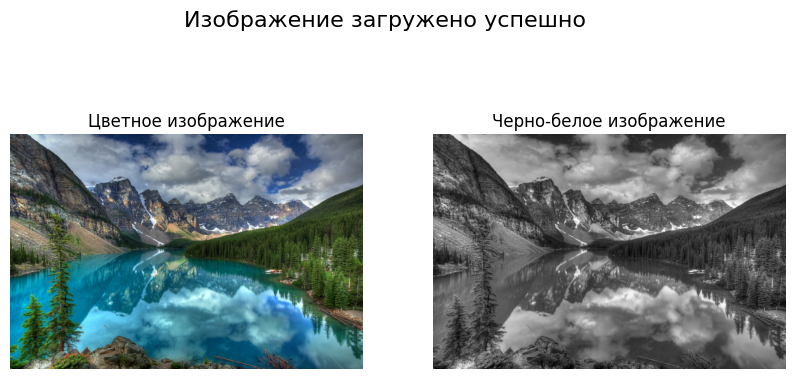

In [38]:
# Введите в переменную path путь к изображению
path = 'mountains.jpeg'

img = load_image(path)

# Оператор Собеля Gy

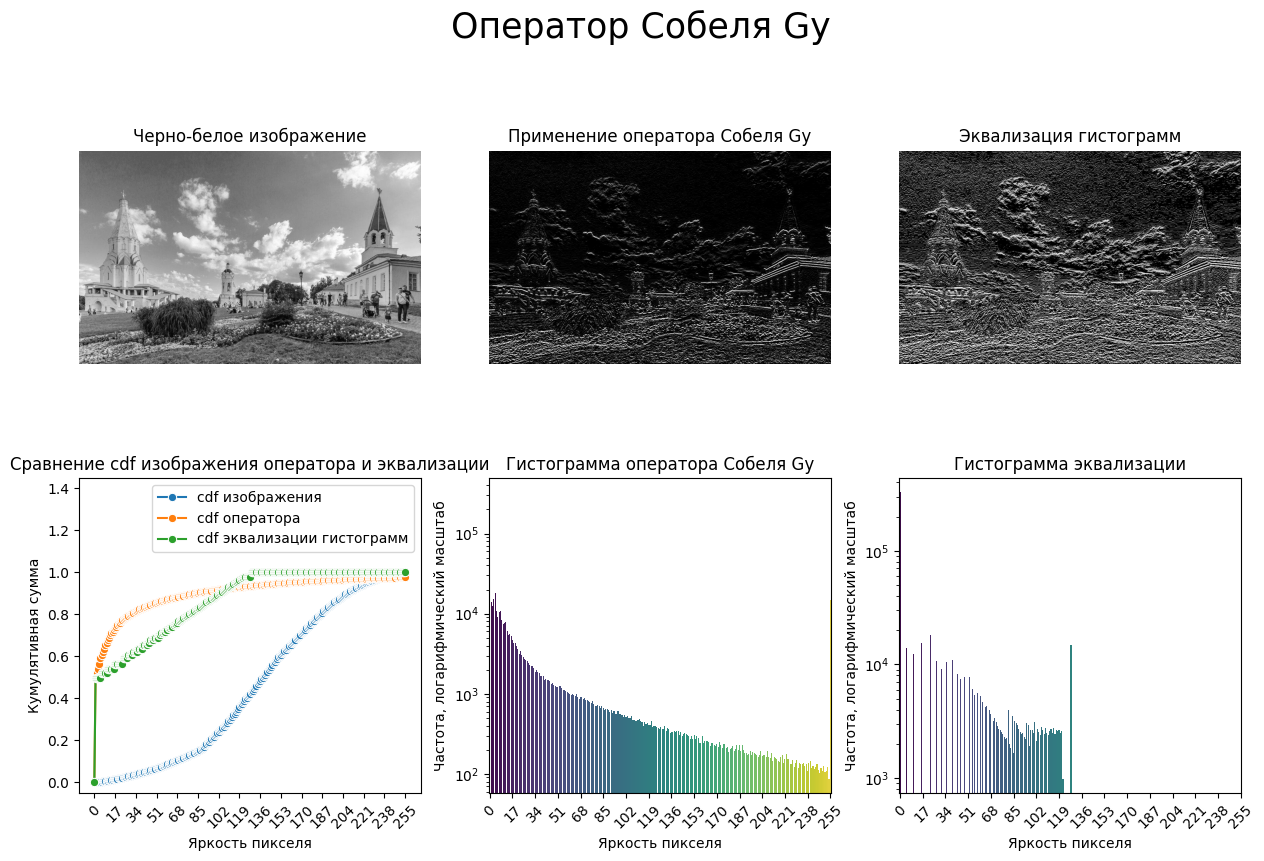

Оператор был вычислен за 8.6 секунд
Эквализация гистограмм была вычислена за 1.55 секунд
cdf был вычислен за 0.16 секунд
Гистограмма изображения оператора была вычислена за 0.38 секунд
Гистограмма изображения эквализованного оператора была вычислена за 0.38 секунд


In [15]:
# Отобразим работу оператора Собеля Gy
show_info(img, mode='Sobel Gy')

# Оператор Собеля Gx

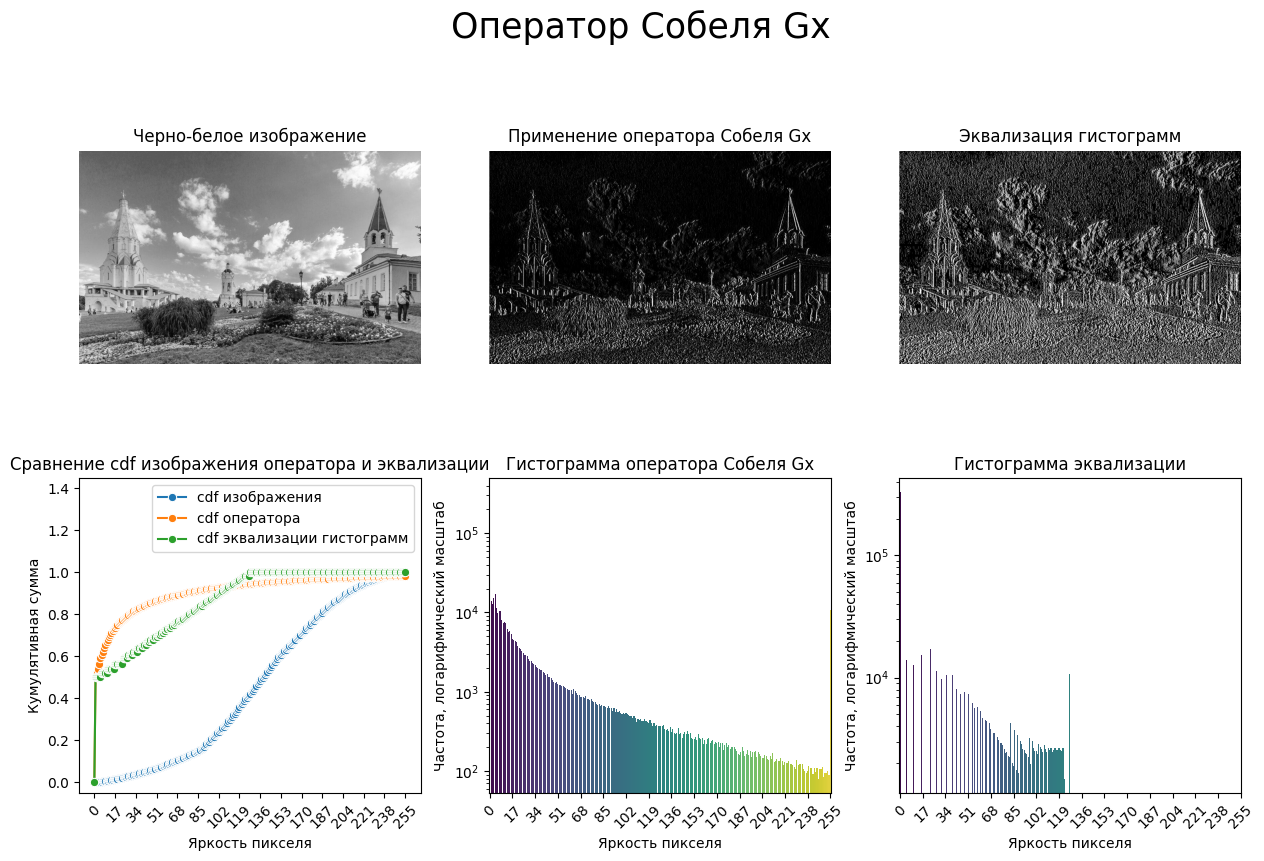

Оператор был вычислен за 8.07 секунд
Эквализация гистограмм была вычислена за 1.6 секунд
cdf был вычислен за 0.15 секунд
Гистограмма изображения оператора была вычислена за 0.4 секунд
Гистограмма изображения эквализованного оператора была вычислена за 0.4 секунд


In [17]:
# Отобразим работу оператора Собеля Gx
show_info(img, mode='Sobel Gx')

# Совместное использование операторов Собеля Gx и Gy 1

$$\mathcal \nabla f\approx |G_x| + |G_y|$$

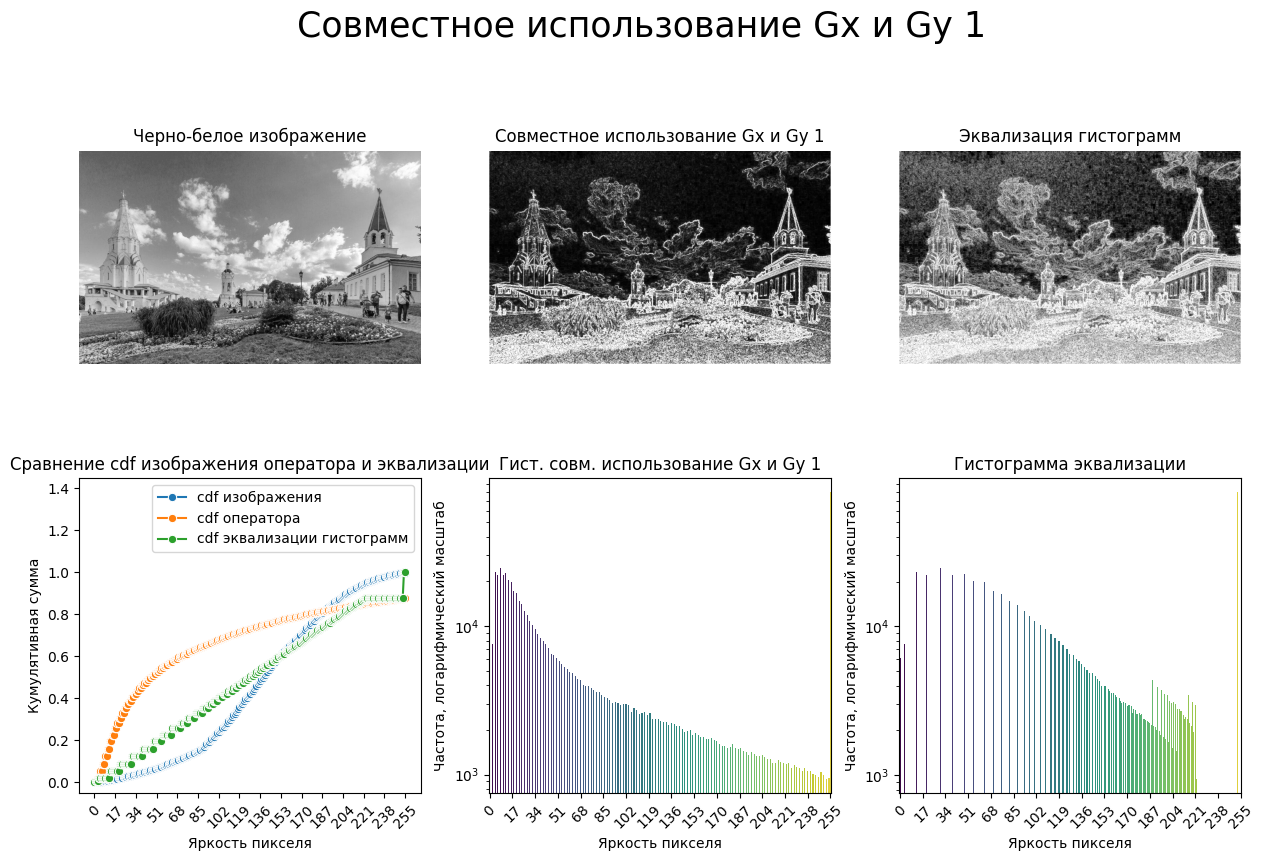

Оператор был вычислен за 21.04 секунд
Эквализация гистограмм была вычислена за 1.58 секунд
cdf был вычислен за 0.15 секунд
Гистограмма изображения оператора была вычислена за 0.37 секунд
Гистограмма изображения эквализованного оператора была вычислена за 0.36 секунд


In [18]:
# Отобразим работу оператора Собеля ∇f
show_info(img, mode='Sobel Gx & Gy abs')

# Совместное использование операторов Собеля Gx и Gy 2

$$\mathcal f= \sqrt {G_x^2 + G_y^2}$$

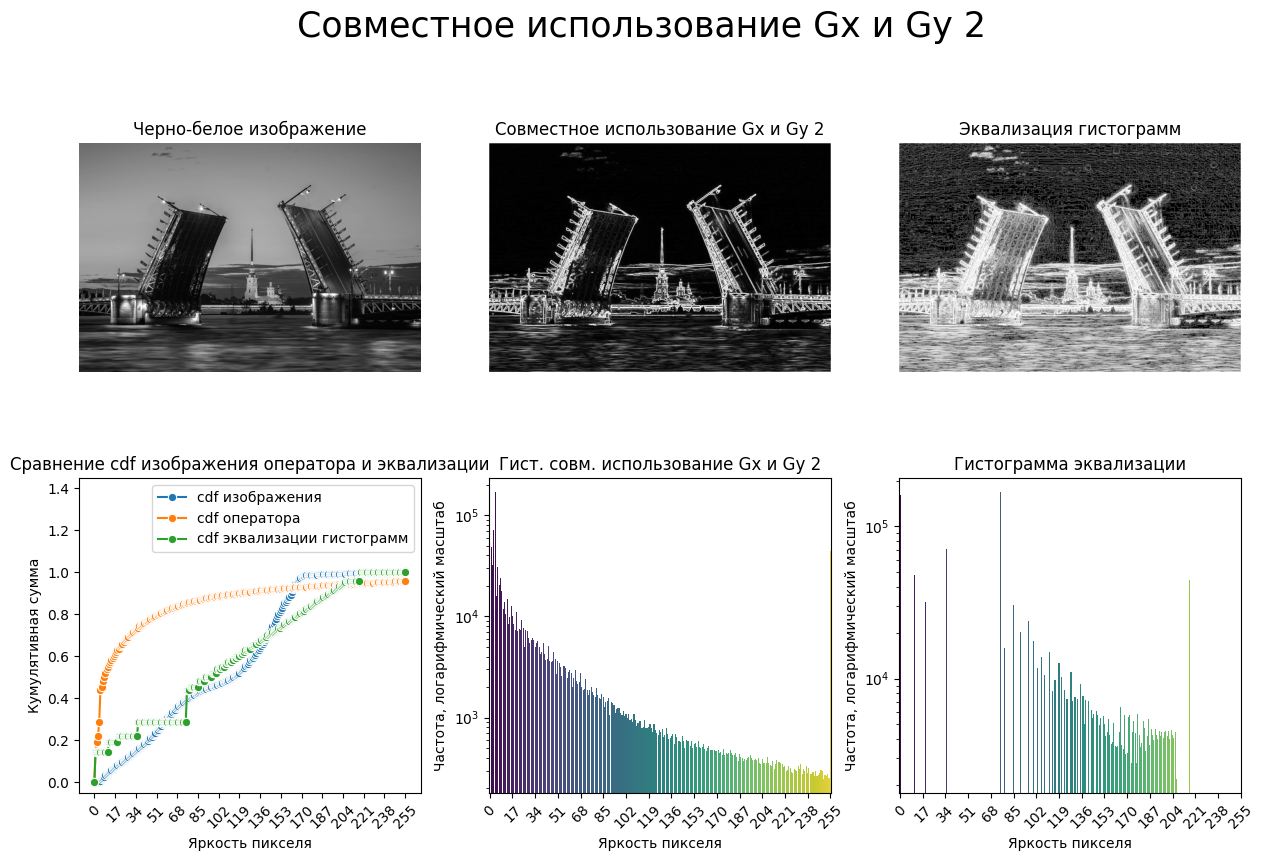

Оператор был вычислен за 22.69 секунд
Эквализация гистограмм была вычислена за 2.64 секунд
cdf был вычислен за 0.22 секунд
Гистограмма изображения оператора была вычислена за 0.63 секунд
Гистограмма изображения эквализованного оператора была вычислена за 0.63 секунд


In [27]:
# Отобразим работу оператора Собеля f
show_info(img, mode='Sobel Gx & Gy sqrt')

# Оператор Лапласа

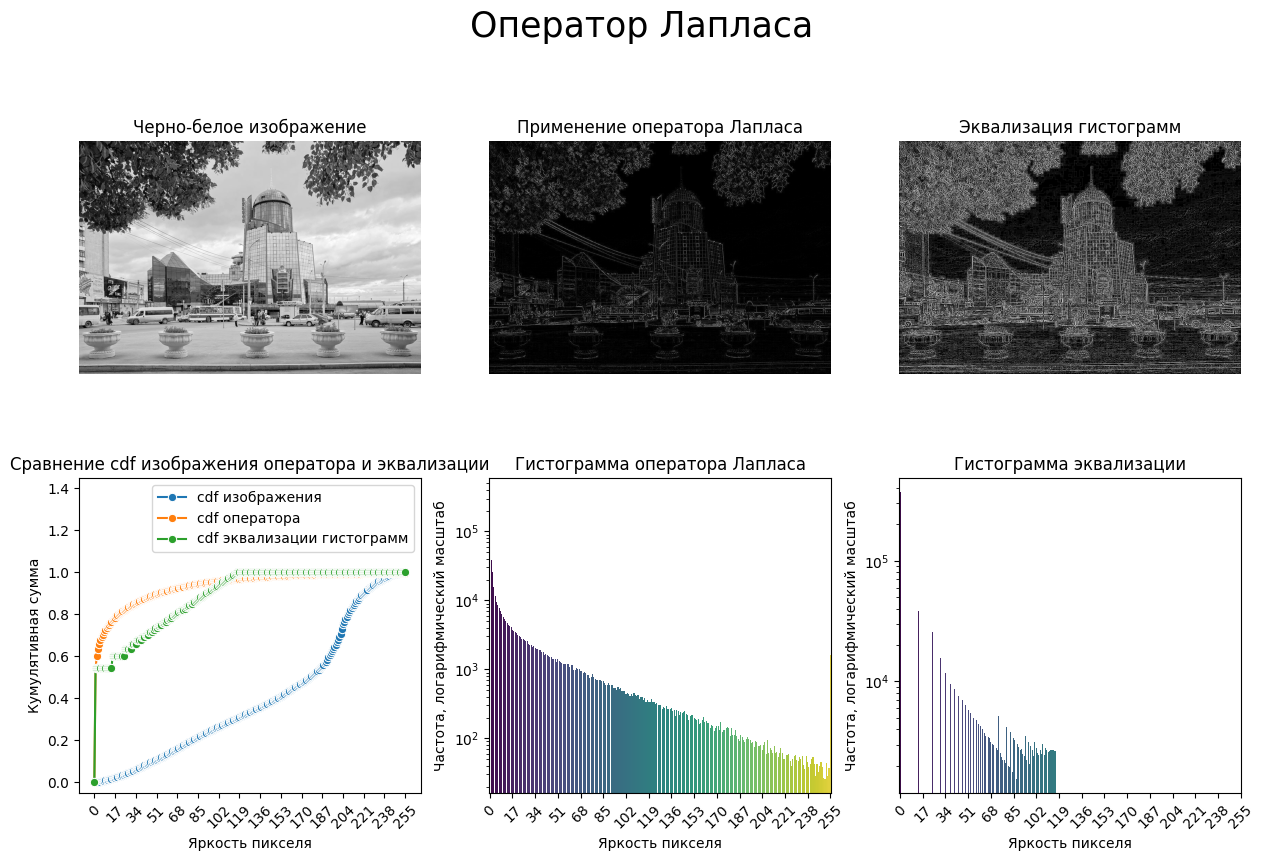

Оператор был вычислен за 8.25 секунд
Эквализация гистограмм была вычислена за 1.68 секунд
cdf был вычислен за 0.14 секунд
Гистограмма изображения оператора была вычислена за 0.39 секунд
Гистограмма изображения эквализованного оператора была вычислена за 0.39 секунд


In [32]:
# Отобразим работу оператора Лапласа
show_info(img, mode='laplace')

# Оператор Робертса Hr

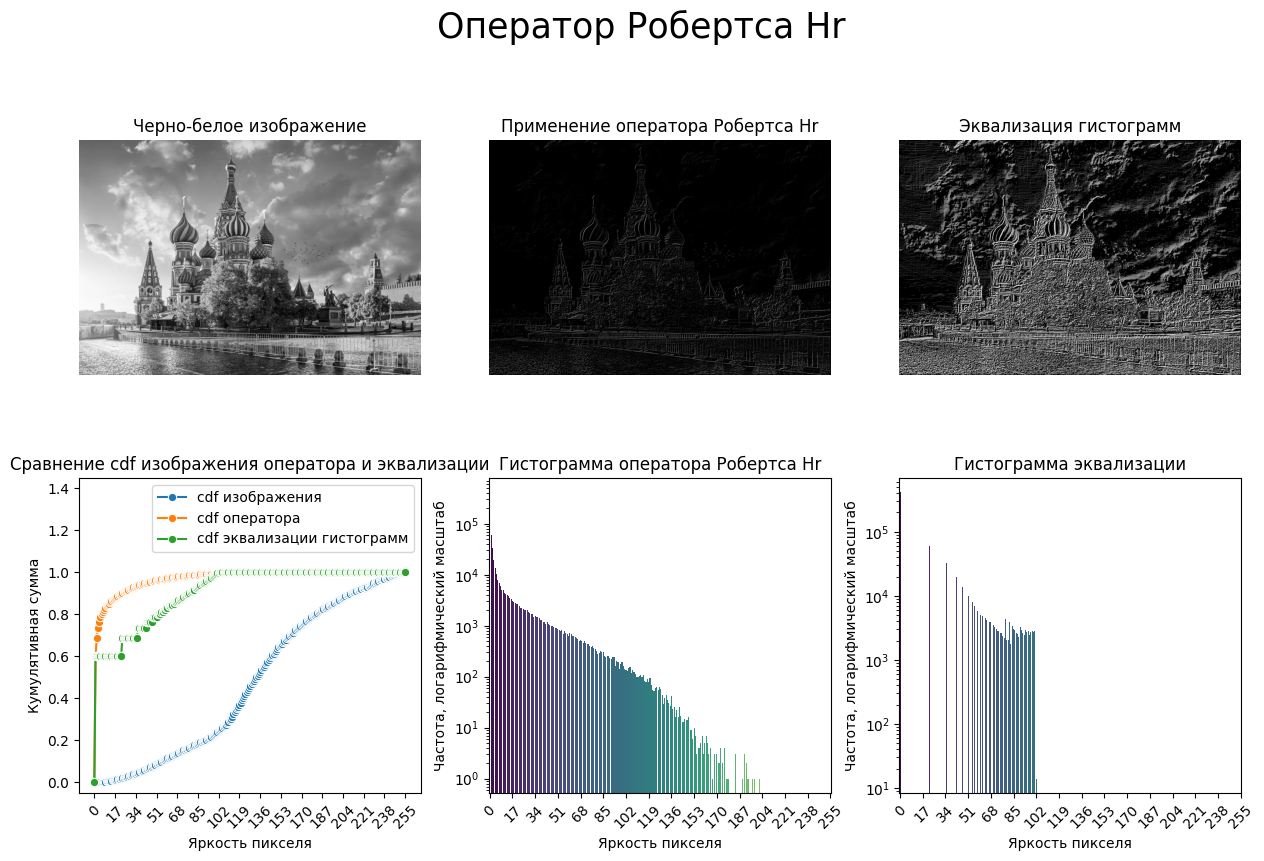

Оператор был вычислен за 8.43 секунд
Эквализация гистограмм была вычислена за 1.7 секунд
cdf был вычислен за 0.15 секунд
Гистограмма изображения оператора была вычислена за 0.39 секунд
Гистограмма изображения эквализованного оператора была вычислена за 0.39 секунд


In [30]:
# Отобразим работу оператора Робертса Hr
show_info(img, mode='robertz Hr')

# Оператор Робертса Hc

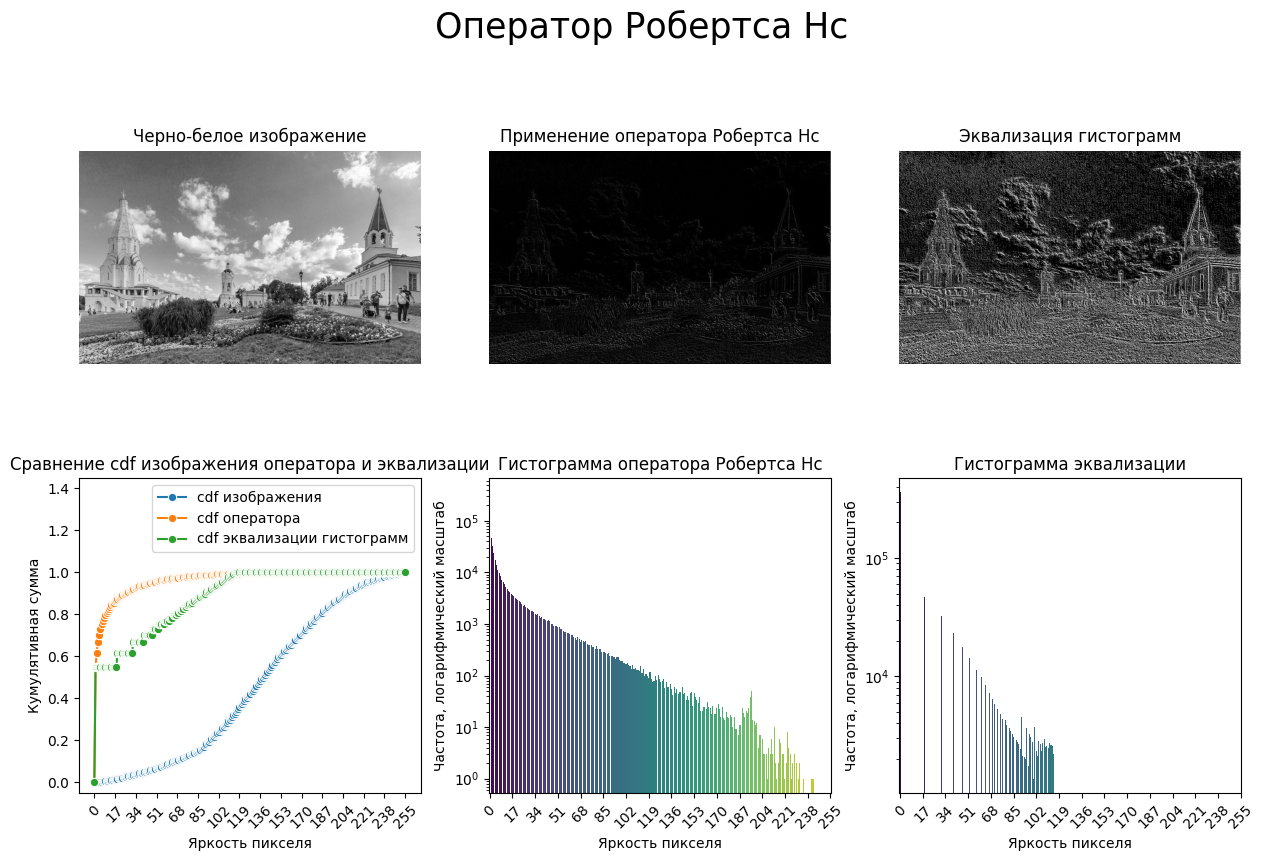

Оператор был вычислен за 7.76 секунд
Эквализация гистограмм была вычислена за 1.59 секунд
cdf был вычислен за 0.14 секунд
Гистограмма изображения оператора была вычислена за 0.39 секунд
Гистограмма изображения эквализованного оператора была вычислена за 0.38 секунд


In [22]:
# Отобразим работу оператора Робертса Hc
show_info(img, mode='robertz Hc')

# Совместное действие операторов Робертса Hr и Hc

$$\mathcal y_R=|\Delta_{R1}| + |\Delta_{R2}|$$

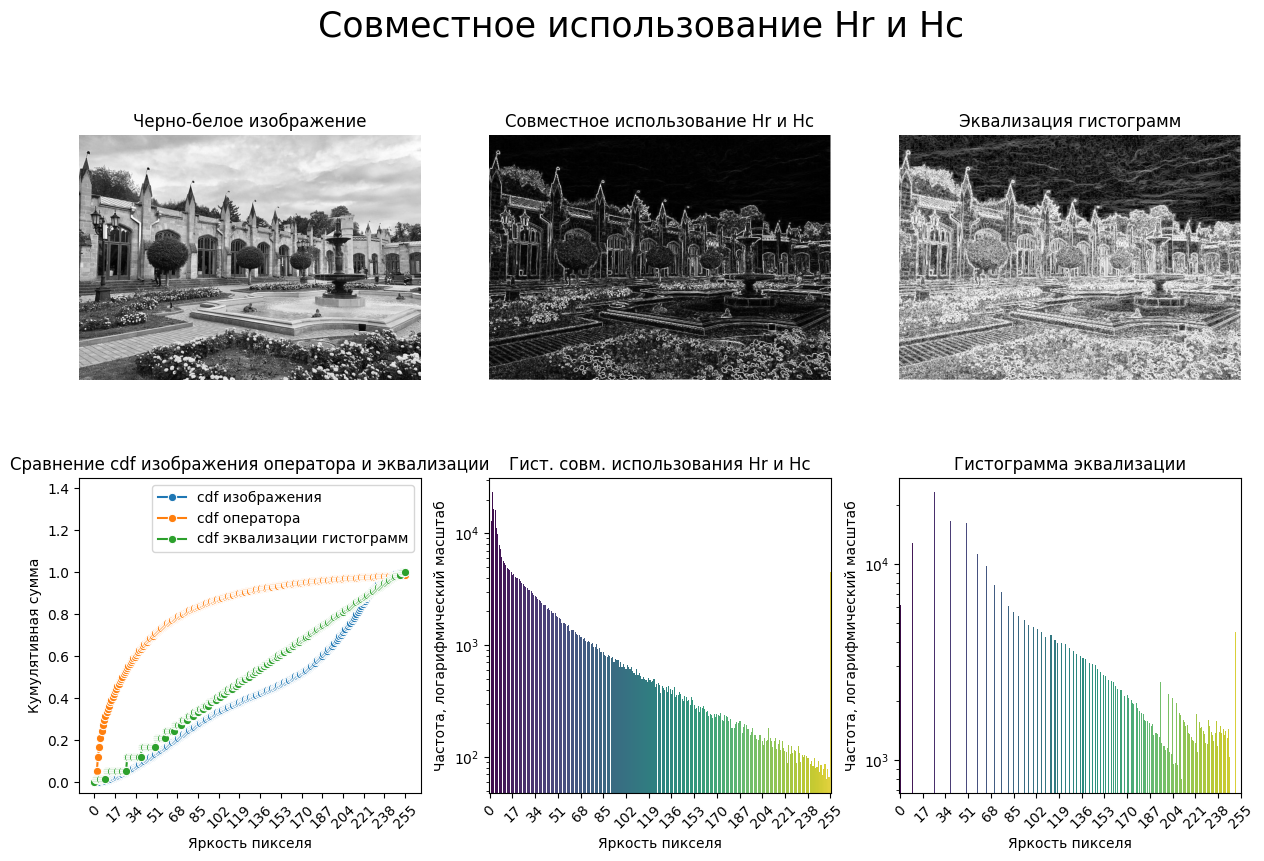

Оператор был вычислен за 6.79 секунд
Эквализация гистограмм была вычислена за 0.85 секунд
cdf был вычислен за 0.15 секунд
Гистограмма изображения оператора была вычислена за 0.19 секунд
Гистограмма изображения эквализованного оператора была вычислена за 0.19 секунд


In [37]:
# Отобразим работу оператора Робертса yR
show_info(img, mode='robertz Hr & Hc')

# Сравнительный анализ операторов

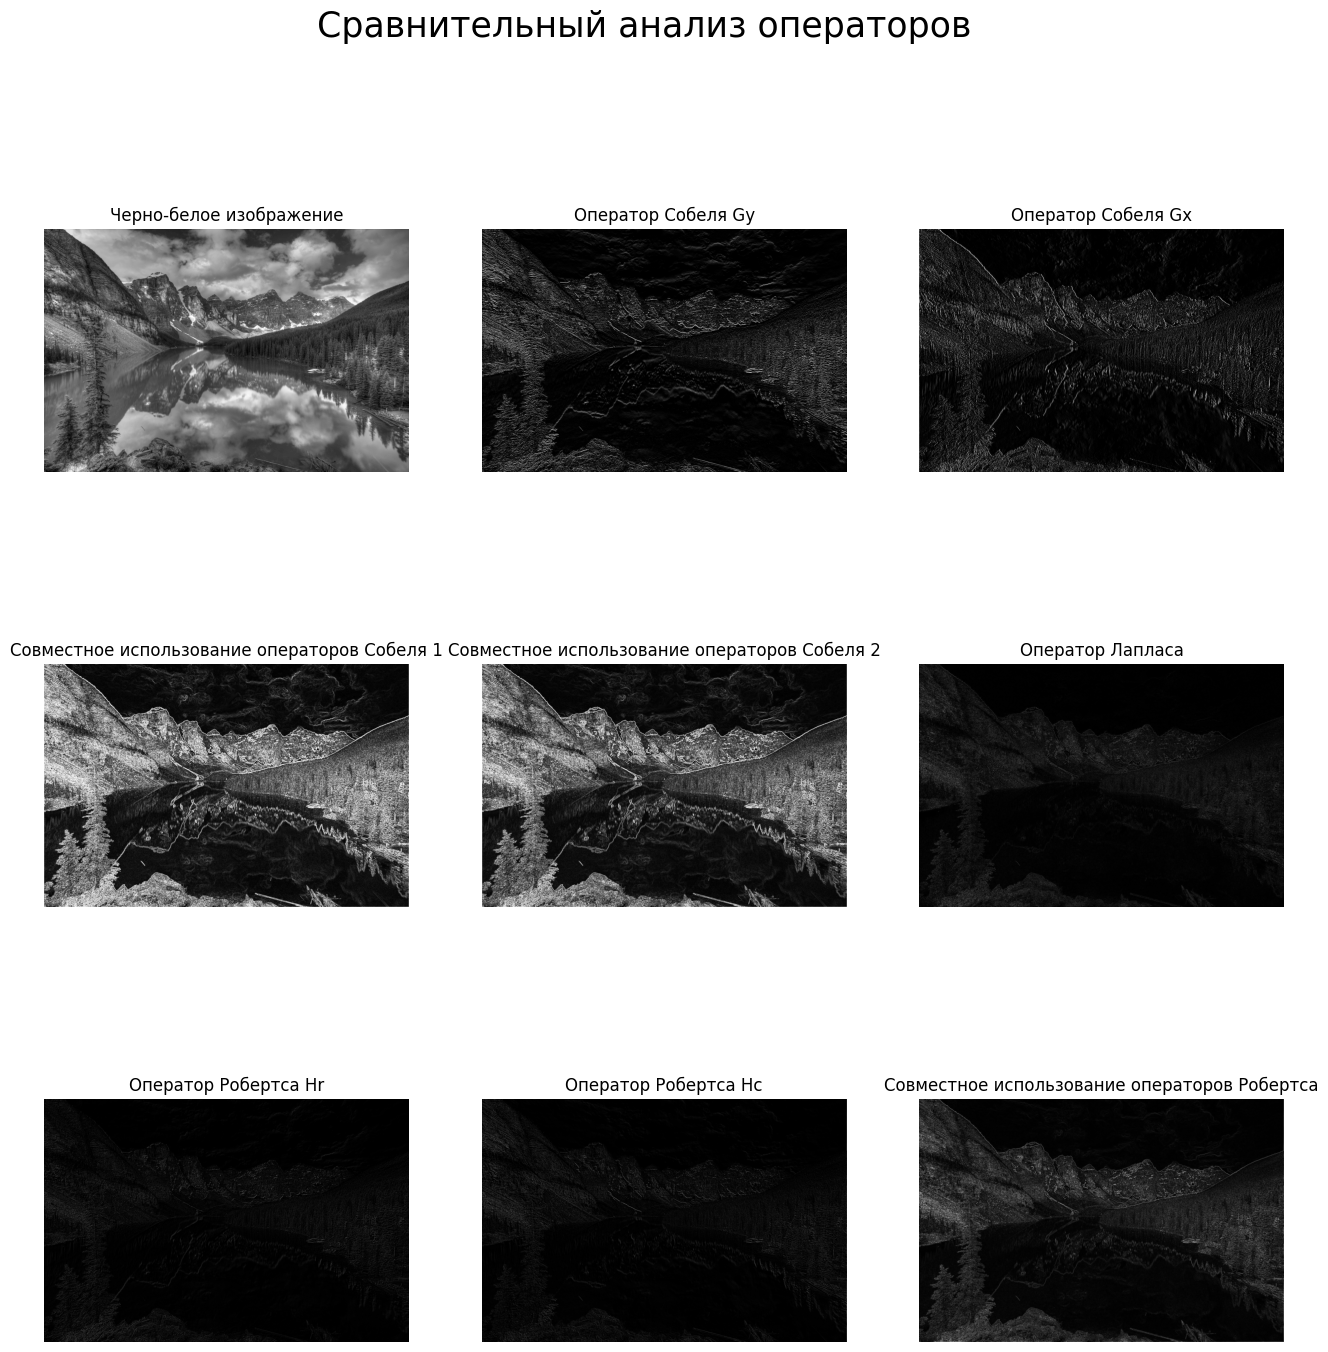

Оператор Собеля Gy был вычислен за 32.62 секунд
Оператор Собеля Gx был вычислен за 30.58 секунд
Совместное действие оператора Собеля Gx и Gy 1 было вычислено за 55.05 секунд
Совместное действие оператора Собеля Gx и Gy 2 было вычислено за 56.24 секунд
Оператор Лапласа был вычислен за 32.44 секунд
Оператор Робертса Hr был вычислен за 30.94 секунд
Оператор Робертса Hc был вычислен за 38.6 секунд
Совместное действие оператора Робертса Hr и Hc было вычислено за 55.24 секунд


In [39]:
# Отобразим сравнение работы операторов
show_compare_operator(img)

# Сравнительный анализ эквализованных гистограмм операторов

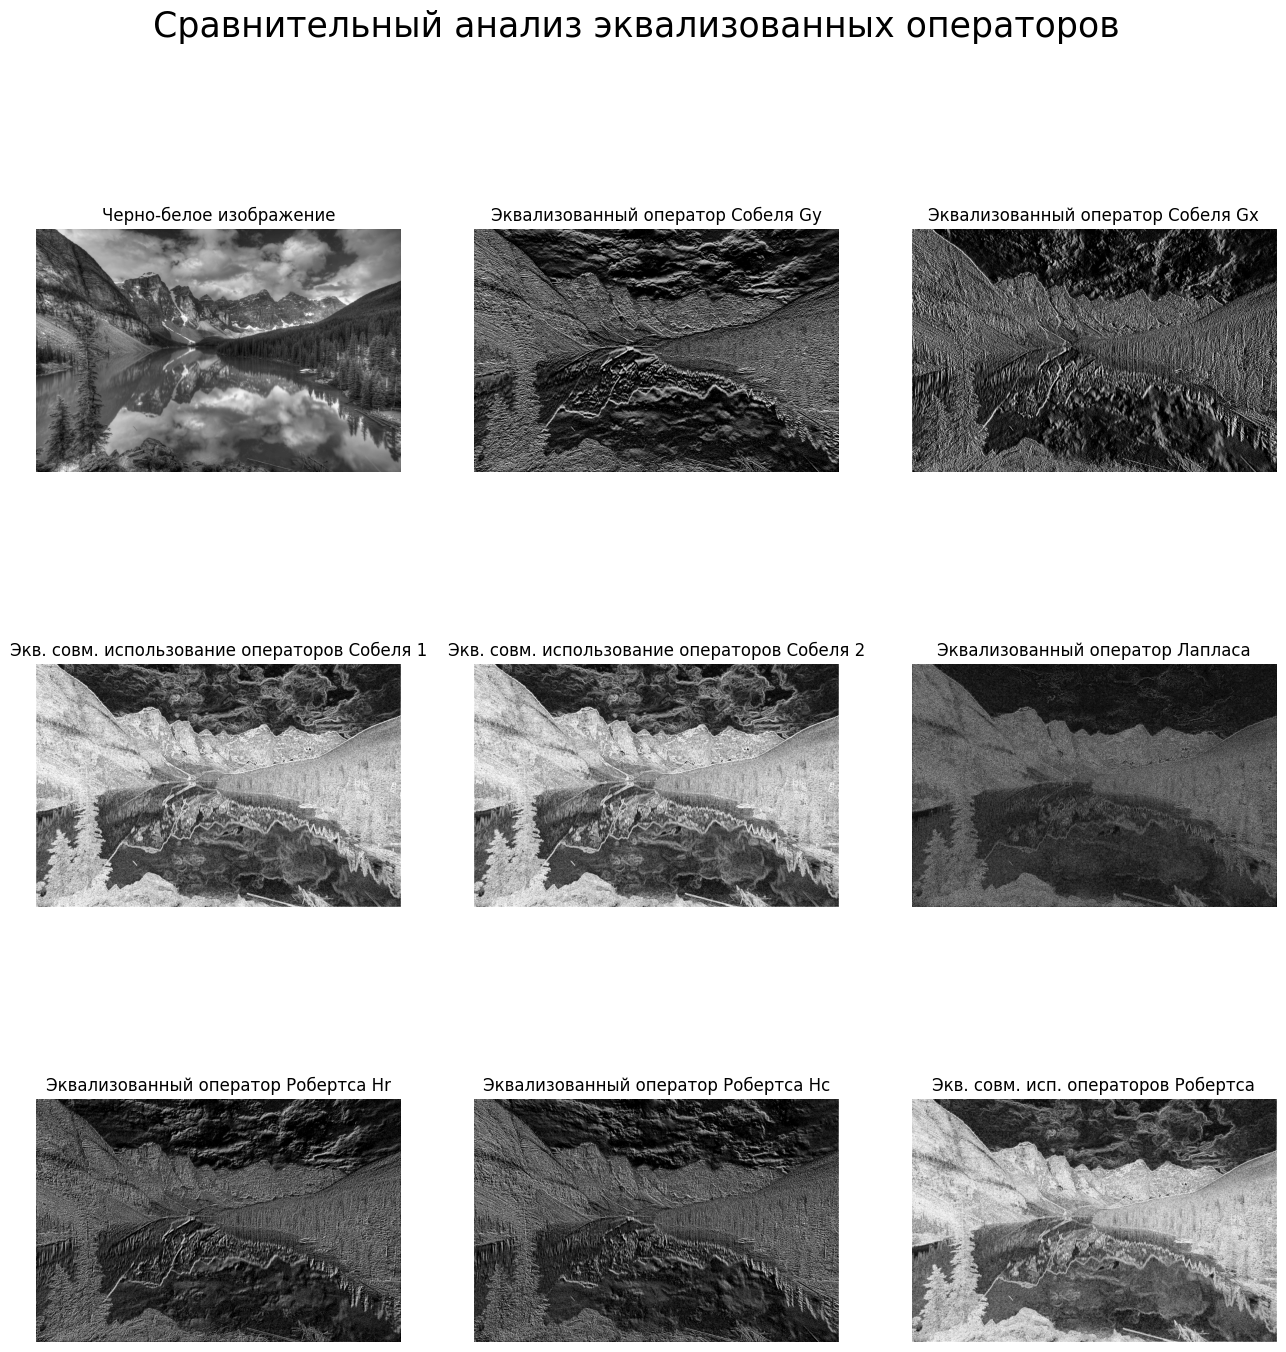

Эквализованный оператор Собеля Gy был вычислен за 7.2 секунд
Эквализованный оператор Собеля Gx был вычислен за 7.99 секунд
Эквализованное совместное действие оператора Собеля Gx и Gy 1 было вычислено за 8.38 секунд
Эквализованное совместное действие оператора Собеля Gx и Gy 2 было вычислено за 6.97 секунд
Эквализованный оператор Лапласа был вычислен за 8.53 секунд
Эквализованный оператор Робертса Hr был вычислен за 6.73 секунд
Эквализованный оператор Робертса Hc был вычислен за 8.47 секунд
Эквализованное совместное действие оператора Робертса было вычислено за 7.66 секунд


In [40]:
# Отобразим сравнение работы эквализованных операторов
show_compare_equalization_operator(img)